In [1]:
'''Task 2:  Plot relevant quantities (e.g. histograms, windroses, spatial plots or maps, time series, 
scatterplots, etc.) of the input data and describe potential deficiencies (e.g. data gaps). 
Compare the lidar with the reanalysis data for the period lidar data is available.'''



'Task 2:  Plot relevant quantities (e.g. histograms, windroses, spatial plots or maps, time series, \nscatterplots, etc.) of the input data and describe potential deficiencies (e.g. data gaps). \nCompare the lidar with the reanalysis data for the period lidar data is available.'

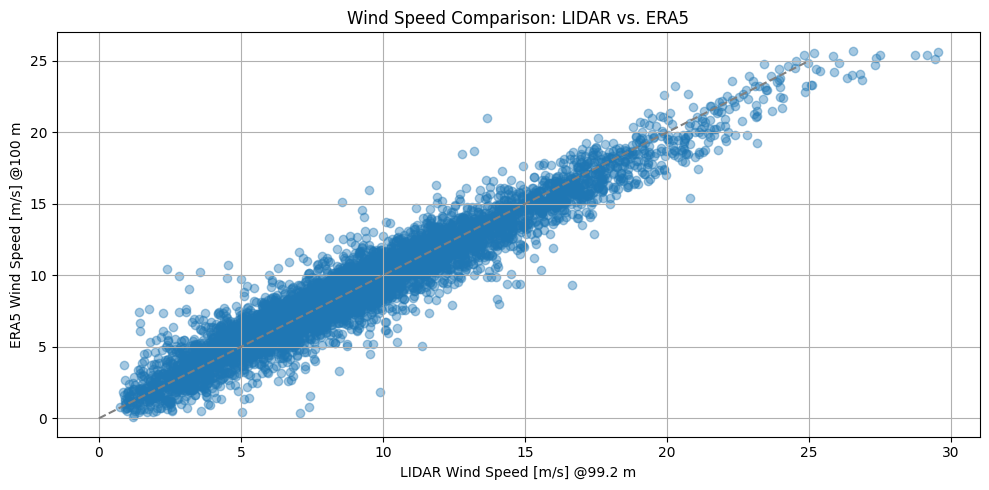


Missing Values per Column:
 WS-99.2    44
WD-99.2    59
WS100       0
WD100       0
dtype: int64


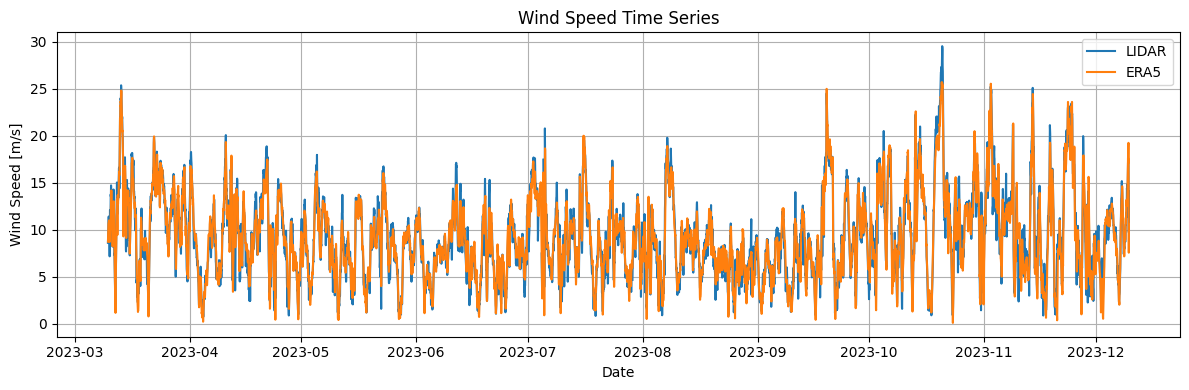

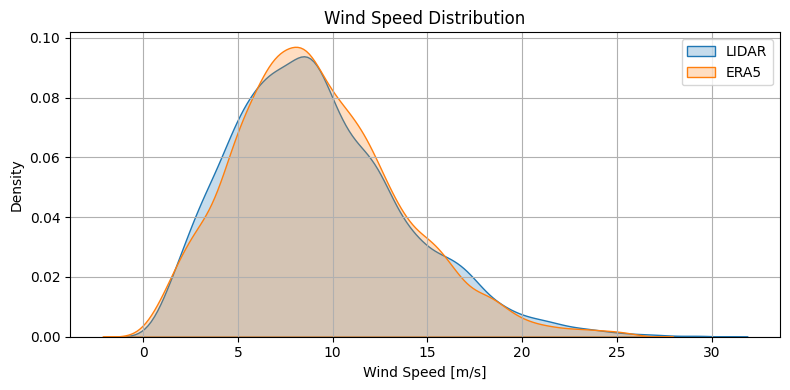

C:\Users\Marlene\AppData\Local\Temp\ipykernel_18500\3812245119.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


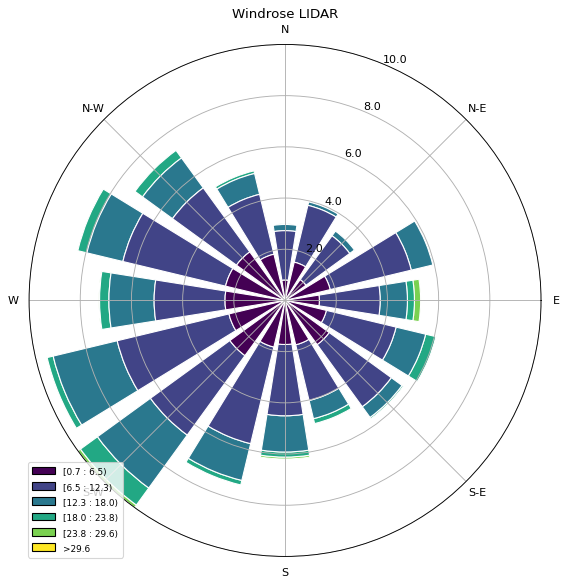


Pearson Correlation between LIDAR and ERA5 Wind Speeds: 0.961


C:\Users\Marlene\AppData\Local\Temp\ipykernel_18500\3812245119.py:94: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


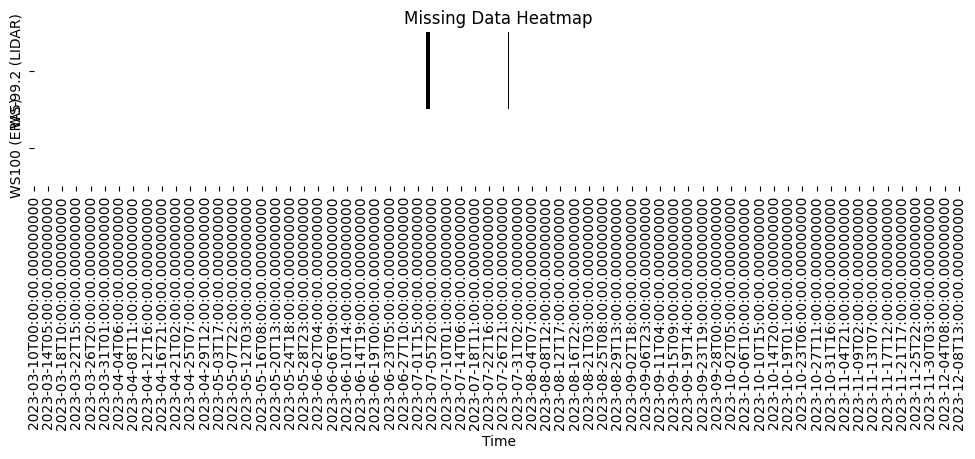

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Optional: Windrose library
try:
    from windrose import WindroseAxes
except ImportError:
    WindroseAxes = None

# Load and clean data (reuse from ReadingData)
def read_ts_csv(filename):
    df = pd.read_csv(filename, parse_dates=['Unnamed: 0'])
    df.rename(columns={df.columns[0]: "Time"}, inplace=True)
    df.drop_duplicates(subset='Time', inplace=True)
    df.replace(-999, np.nan, inplace=True)
    return df

# Load data
data_ERA5 = read_ts_csv('reanalysis.csv')
data_LIDAR = read_ts_csv('measurements/lidar.csv')

# Resample hourly
data_ERA5 = data_ERA5.resample('h', on='Time').mean()
data_LIDAR = data_LIDAR.resample('h', on='Time').mean()

# Merge and filter
data_mrgd = pd.merge(data_LIDAR, data_ERA5, how='right', on='Time')
data_mrgd.index = pd.to_datetime(data_mrgd.index)

# Focus only on overlapping time periods
data_overlap = data_mrgd.loc[data_LIDAR.index[0]:data_LIDAR.index[-1]]

# 1. SCATTERPLOTS
plt.figure(figsize=(10, 5))
plt.scatter(data_overlap['WS-99.2'], data_overlap['WS100'], alpha=0.4)
plt.xlabel("LIDAR Wind Speed [m/s] @99.2 m")
plt.ylabel("ERA5 Wind Speed [m/s] @100 m")
plt.title("Wind Speed Comparison: LIDAR vs. ERA5")
plt.grid(True)
plt.plot([0, 25], [0, 25], '--', color='gray')  # 1:1 line
plt.tight_layout()
plt.show()

# 2. TIME SERIES GAP ANALYSIS
missing_counts = data_overlap.isna().sum()
print("\nMissing Values per Column:\n", missing_counts)

plt.figure(figsize=(12, 4))
plt.plot(data_overlap.index, data_overlap['WS-99.2'], label='LIDAR')
plt.plot(data_overlap.index, data_overlap['WS100'], label='ERA5')
plt.xlabel("Date")
plt.ylabel("Wind Speed [m/s]")
plt.title("Wind Speed Time Series")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. HISTOGRAM COMPARISON (already done in ReadingData, optionally expand)
# Already included in the foundation. Optionally show PDF overlaid:
plt.figure(figsize=(8, 4))
sns.kdeplot(data_overlap['WS-99.2'].dropna(), label='LIDAR', fill=True)
sns.kdeplot(data_overlap['WS100'].dropna(), label='ERA5', fill=True)
plt.xlabel("Wind Speed [m/s]")
plt.title("Wind Speed Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. WINDROSE (optional, requires `windrose`)
if WindroseAxes:
    ax = WindroseAxes.from_ax()
    ax.bar(data_overlap['WD-99.2'], data_overlap['WS-99.2'], normed=True, opening=0.8, edgecolor='white')
    ax.set_title("Windrose LIDAR")
    ax.set_legend()
    #plt.tight_layout()
    plt.show()
else:
    print("Install `windrose` for windrose plots: pip install windrose")

# 5. CORRELATION ANALYSIS
correlation = data_overlap[['WS-99.2', 'WS100']].corr().iloc[0, 1]
print(f"\nPearson Correlation between LIDAR and ERA5 Wind Speeds: {correlation:.3f}")

# Optional: Heatmap of missing data
plt.figure(figsize=(12, 2))
sns.heatmap(data_overlap[['WS-99.2', 'WS100']].isna().T, cbar=False, cmap='gray_r')
plt.title("Missing Data Heatmap")
plt.yticks([0.5, 1.5], ['WS-99.2 (LIDAR)', 'WS100 (ERA5)'])
plt.tight_layout()
plt.show()


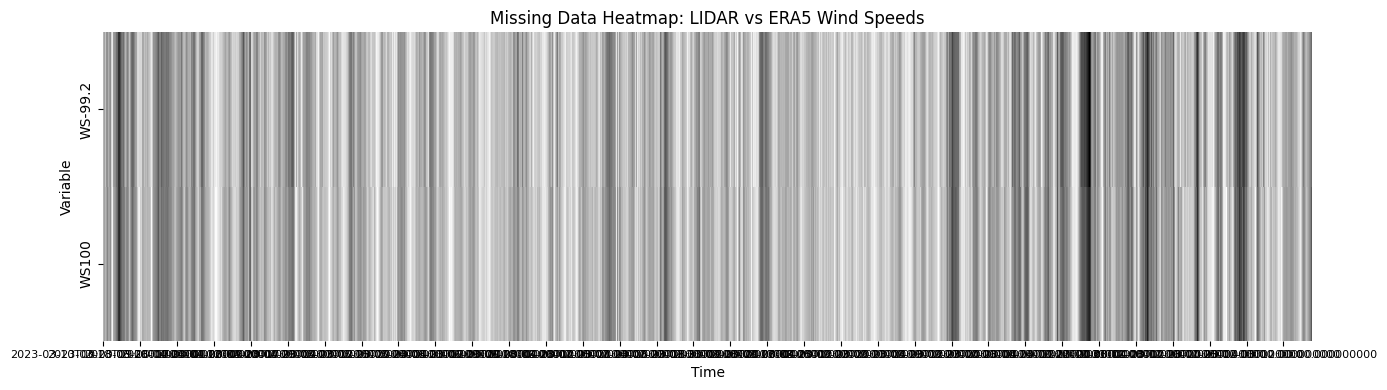

In [ ]:
## second attempt
import seaborn as sns
import matplotlib.pyplot as plt

# Extract the relevant columns and check for NaNs
#missing_data = data_overlap[['WS-99.2', 'WS100']].isna()
# Keep rows where at least one of the columns is NOT NaN
partial_data = data_overlap[['WS-99.2', 'WS100']].dropna(how='any') #or use how='all' -> what's the difference?
missing_data=partial_data

# Ensure the index is datetime, and format it for better readability
missing_data.index = pd.to_datetime(missing_data.index)

# Plot missing data heatmap
plt.figure(figsize=(14, 4))

# Use seaborn to plot
ax = sns.heatmap(
    missing_data.T,           # Transpose so that variables are on the y-axis
    cmap='gray_r',            # White = missing, black = not missing
    cbar=False,               # Remove colorbar for simplicity
    xticklabels=200           # Show fewer x-ticks for readability
)

# Titles and labels
plt.title("Missing Data Heatmap: LIDAR vs ERA5 Wind Speeds")
plt.xlabel("Time")
plt.ylabel("Variable")

# Optional: rotate and format time axis for better display
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()
